<a href="https://colab.research.google.com/github/SugamBhujel/Thesis/blob/main/Thesis_on_Popularity_Bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Research Questions

This thesis investigates popularity bias in collaborative filtering recommender
systems using the MovieLens 32M dataset. The following four research questions
guide the analysis:

**RQ1: Do collaborative filtering models amplify popularity bias relative to
the dataset baseline?**
We measure whether the MF model recommends head items more or less frequently
than they appear in the training data, using amplification score and
ModelHeadShare as key metrics.

**RQ2: How can popularity bias be measured across multiple dimensions?**
We evaluate bias using four complementary metrics ModelHeadShare,
Amplification, Exposure Gini, and Mean ΔGAP to capture different aspects
of how popularity influences recommendations.

**RQ3: What is the fairness accuracy trade-off when applying a popularity
penalty?**
We sweep lambda from 0.0 to 1.0 and measure how Recall@10 and NDCG@10
change alongside fairness metrics to map the full trade-off frontier.

**RQ4: Does the popularity penalty change the model's decision making
mechanism or just its output?**
We use Spearman correlation and SHAP analysis to investigate whether the
penalty structurally changes how the model scores items, not just which
items end up in the final recommendation list.



In [1]:
# =============================================================================
# Imports & style
# =============================================================================


# These three are used to deal with files on disk os is used to check if folders exist,
# zipfile is used to open the dataset zip file, and Path will give us clean file paths
# regardless of slash orientation on either windows or mac:
import os
import zipfile
from pathlib import Path

# numpy is the math library nearly everything we calculate in this project
# (dot product, array operation, mean) goes through numpy.
import numpy as np
# pandas will take our raw csv file and turn it into a table we can filter, group, and query:
import pandas as pd
# matplotlib draws all the graphs mpl gives us access to colormaps
# and other low level settings, pyplot is the simpler drawing interface
import matplotlib as mpl
import matplotlib.pyplot as plt
# spearmanr measures rank correlation we use it in Step 11 to check
# whether item popularity correlates with ranking scores
from scipy.stats import spearmanr
# RandomForestRegressor builds the surrogate model in Step 12
# we need a model that SHAP can explain, and Random Forests work well for that
from sklearn.ensemble import RandomForestRegressor
# train_test_split splits the surrogate dataset so we can evaluate
# the Random Forest fairly without testing on data it was trained on
from sklearn.model_selection import train_test_split
# shap explains which features drove each prediction in the surrogate model,
# giving us mechanism level evidence for why reranking works
import shap
# These settings apply to every figure automatically so we don't have
# to repeat styling code in each plot cell
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F9FA",
    "axes.edgecolor":    "#CCCCCC",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
    "axes.labelsize":    11,
    "axes.labelcolor":   "#333333",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.fontsize":   10,
    "lines.linewidth":   2.4,
    "lines.markersize":  8,
})

# One consistent color palette used across all figures
# so the same concept always appears in the same color
BLUE   = "#2E86AB" # accuracy metrics and tail-preferring users
ORANGE = "#E07A5F" # fairness metrics and head-preferring users
GREEN  = "#3BB273" # coverage and mid users
PURPLE = "#7B5EA7" # mechanism / correlation plots
GREY   = "#888888" # reference lines and neutral annotations


The first layer consists of data handling, using os, zipfile, and pathlib to load and extract file(s) from your system; using pandas to organize the rating data into an easily searchable table and using numpy to perform mathematical operations on top of that table (dot product, mean, array, etc.) and random number generation. The second layer consists of machine learning/statistics using scikit-learn's Random Forest model to produce an MF score proxy; and scipy.stats.spearmanr to measure the relationship between the item popularity and ranking scores based on lambda. The third layer includes visualization/explanation using shap to break down what features were used to make each prediction by the surrogate model and matplotlib to create the required graphs to support your thesis.

In [2]:
# =============================================================================
# STEP 1: Load the Data
# =============================================================================

# Only extract if the folder doesn't exist yet
# this prevents re-extracting every time we restart the notebook
zip_path = Path("ml-32m.zip")
out_dir  = Path("ml-32m")

if not out_dir.exists():
    out_dir.mkdir(parents=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    print("Extracted dataset successfully.")

# Load the ratings file this becomes the master table for everything else
ratings_path = Path("ml-32m/ml-32m/ratings.csv")
ratings = pd.read_csv(ratings_path)
# Quick sanity check confirm the data loaded correctly before doing anything with it
print("Raw dataset shape:", ratings.shape)
print(ratings.head())

Extracted dataset successfully.
Raw dataset shape: (32000204, 4)
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858


The code: extracts the MovieLens 32M dataset and loads the ratings.csv file from it into a pandas DataFrame. Then it outputs the total number of ratings in the database (32 million ratings; 4 column ratings), as well as some sample data to confirm that the data is stored appropriately.

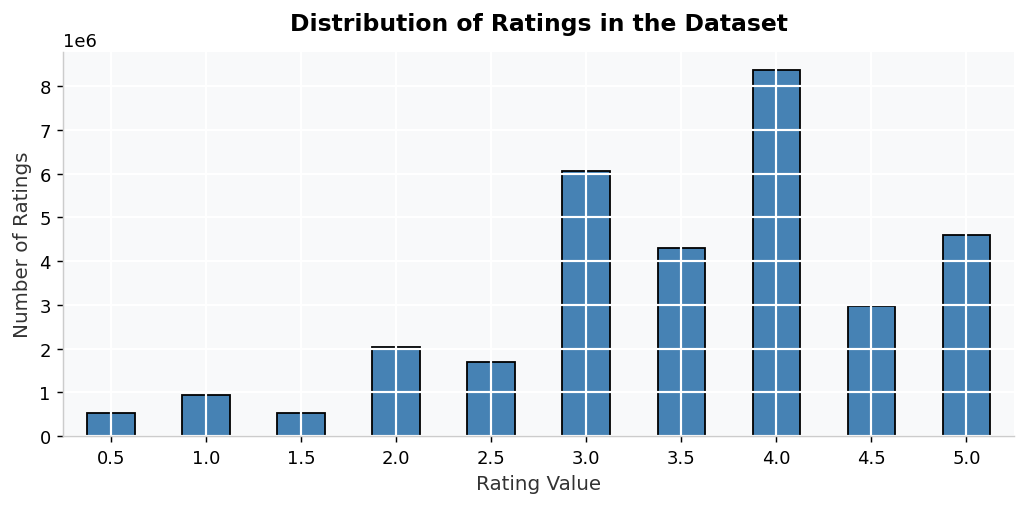

In [3]:
# Show how ratings are distributed across the 0.5-5.0 scale
# so we can see whether users tend to rate positively or negatively
plt.figure(figsize=(8, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Rating Value")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Ratings in the Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar graph illustrates how users have dispersed their ratings through out the 0.5-5.0 rating scales. The data shows a definite skew towards higher ratings and the most rated was 4.0, then 3.0, and lastly 5.0. Very low ratings (i.e., 0.5, 1.0, 1.5) were very rare. The positive skew is an important point of reference for the bias analysis because users typically will choose and enjoy movies that they have rated, the training data already has a tendency to over represent well known popular movies, thus establishing the ground work for the popularity bias problem studied in this thesis.

In [4]:
# =============================================================================
# STEP 2: Filter & Split
# =============================================================================
# Keep only the three columns we actually need drop timestamp

df = ratings[["userId", "movieId", "rating"]].copy()
# Users with very few ratings don't give the model enough to learn from,
# and rarely-rated movies add noise without useful signal

MIN_USER_RATINGS = 20   # drop users with fewer than this many ratings
MIN_ITEM_RATINGS = 5    # drop items with fewer than this many ratings

user_counts = df.groupby("userId").size()
item_counts = df.groupby("movieId").size()

df = df[df["userId"].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]
df = df[df["movieId"].isin(item_counts[item_counts >= MIN_ITEM_RATINGS].index)].copy()

print(f"After filtering: {df.shape[0]} ratings | "
      f"{df['userId'].nunique()} users | {df['movieId'].nunique()} items")

# Assign a random number to each rating so we can shuffle within each user
# we need to split per user so every user appears in both train and test
SEED = 42
rng  = np.random.default_rng(SEED)

df["rand"] = rng.random(len(df))
df = df.sort_values(["userId", "rand"], kind="mergesort")

# Number each rating within its user group (0, 1, 2, ...) then
# mark the first 80% as training data for that user
df["rank_in_user"] = df.groupby("userId").cumcount()
df["user_total"]   = df.groupby("userId")["movieId"].transform("size")
df["is_train"]     = df["rank_in_user"] < (0.8 * df["user_total"]).astype(int)

train_df = df.loc[df["is_train"],  ["userId", "movieId", "rating"]].copy()
test_df  = df.loc[~df["is_train"], ["userId", "movieId", "rating"]].copy()

print(f"Train: {train_df.shape} | Test: {test_df.shape}")

After filtering: 31921467 ratings | 200948 users | 43884 items
Train: (25457887, 3) | Test: (6463580, 3)


The code above also cleans the original dataset by filtering out all users who had less than 20 ratings, and all movies which were rated less than 5 times. This cleaning process was done to reduce the sparseness of the dataset, and resulted in approximately 25,457,887 training ratings, and 6,463,580 test ratings. Training and testing data was split per user, 80% for training, 20% for testing, and a fixed random seed was used so the same splits would be generated for reproducibility.

In [5]:
# =============================================================================
# STEP 3: Build Index Mappings
# =============================================================================
# Grab the unique users and items that appear in training
# these define the "vocabulary" the model will learn
user_ids    = train_df["userId"].unique()
item_ids    = train_df["movieId"].unique()


# Map original IDs to clean integers starting at 0
# matrix operations like dot products require gapless sequential indices,
# but the raw IDs in the dataset can have large gaps between them
user_to_idx = {u: i for i, u in enumerate(user_ids)}   # userId  -> index
item_to_idx = {m: i for i, m in enumerate(item_ids)}   # movieId -> index

num_users = len(user_ids)
num_items = len(item_ids)

print(f"Users: {num_users} | Items: {num_items}")

# Convert to a flat array of (user_index, item_index, rating) rows
# NumPy arrays are much faster to loop through than DataFrames,
# which matters when we're iterating over 25 million rows per epoch
train_data = np.array(
    [(user_to_idx[u], item_to_idx[i], r)
     for u, i, r in zip(train_df["userId"], train_df["movieId"], train_df["rating"])],
    dtype=np.float32
)
print("Training triples shape:", train_data.shape)

Users: 200948 | Items: 43880
Training triples shape: (25457887, 3)


This section of code maps user and movie IDs to sequential clean integer values from 0 up.
In the initial dataset, the user and/or item IDs are all out of sequence - e.g., user ID could go from 12 to 479 to 3204, etc. A key operation such as a dot product or other matrix operation requires that these be sequential arrays with no gaps. Therefore, user_to_idx and item_to_idx are used as look-up tables. They map every one of the original IDs to an appropriate clean index value. This makes it easy to convert the raw training data into (user_index, item_index, rating) tuples, which is how the SGD training loop is designed to run over 25 million rows as quickly and efficiently as possible.
The end result is a total of 200,948 users, 43,880 items, and 25,457,887 training interaction pairs.

In [6]:

# =============================================================================
# STEP 4: Train Matrix Factorization with SGD
# =============================================================================

# Each user and item gets a vector of this many numbers to describe their
# hidden taste profile 32 is a good balance between detail and speed
EMBEDDING_DIM = 32

# How big each weight update is too large and the model overshoots,
# too small and it takes forever to learn anything useful
LR            = 0.01

# Pulls large weights back toward zero after each update
# without this the model memorises training data instead of generalising
REG           = 0.02
# One epoch = one full pass through all 25 million training ratings
EPOCHS        = 10

rng = np.random.default_rng(SEED)

# Start embeddings near zero (small random noise) so no user or item
# has an unfair advantage before training begins
P  = rng.normal(0, 0.1, size=(num_users, EMBEDDING_DIM)).astype(np.float32)  # user embeddings
Q  = rng.normal(0, 0.1, size=(num_items, EMBEDDING_DIM)).astype(np.float32)  # item embeddings
# Biases start at zero the model will learn how generous each user is
# and how well-rated each item is as training progresses
bu = np.zeros(num_users, dtype=np.float32)   # user biases
bi = np.zeros(num_items, dtype=np.float32)   # item biases

# The starting point for every prediction before personalisation kicks in
mu = float(train_df["rating"].mean())         # global average rating

for epoch in range(1, EPOCHS + 1):
    # Shuffle so the model sees ratings in a different order each epoch
    # otherwise it could memorise the sequence rather than learning real patterns
    rng.shuffle(train_data)
    total_loss = 0.0

    for u_f, i_f, r in train_data:
        u = int(u_f)
        i = int(i_f)

        # Combine all four components to predict what this user would rate this item
        pred = mu + bu[u] + bi[i] + float(np.dot(P[u], Q[i]))
        # How wrong were we? Positive error means we predicted too low
        err  = float(r) - pred
        total_loss += err * err

        # Nudge biases in the direction that reduces error,
        # but pull them back slightly with regularization to avoid overfitting
        bu[u] += LR * (err - REG * bu[u])
        bi[i] += LR * (err - REG * bi[i])

        # Save P[u] before overwriting it Q[i] needs the original P[u] value,
        # not the updated one, otherwise the two updates interfere with each other
        Pu_old = P[u].copy()
        P[u]  += LR * (err * Q[i]    - REG * P[u])
        Q[i]  += LR * (err * Pu_old  - REG * Q[i])

    print(f"Epoch {epoch:02d} | SSE Loss: {total_loss:,.2f}")



Epoch 01 | SSE Loss: 18,895,706.00
Epoch 02 | SSE Loss: 17,532,868.00
Epoch 03 | SSE Loss: 16,697,731.00
Epoch 04 | SSE Loss: 15,871,723.00
Epoch 05 | SSE Loss: 15,107,199.00
Epoch 06 | SSE Loss: 14,471,713.00
Epoch 07 | SSE Loss: 13,940,947.00
Epoch 08 | SSE Loss: 13,489,050.00
Epoch 09 | SSE Loss: 13,104,352.00
Epoch 10 | SSE Loss: 12,767,684.00


This code implements a Matrix Factorization model with Stochastic Gradient Descent (SGD) to learn the latent feature representation of both users and items. Each user or item is associated with a 32-dimensional embedding vector a small, ordered list of numbers which will represent unobserved patterns in taste. The model predicts ratings as a function of a global mean, the user's general tendency to be generous (user bias), the item's general tendency to receive high ratings (item bias), and the dot product of the two corresponding vectors (the similarity between the tastes of the two). The model trains for 10 iterations of SGD and at the end of each iteration, it randomly permutes the training set so as to avoid overfitting to the order in which the ratings were received. The size of the updates applied during training are controlled by the learning rate (0.01) and the magnitude of the individual weights is controlled by the regularizer (0.02). At the end of each training iteration, the Sum of Squared Error (SSE) loss decreased indicating that the model is actually improving.

In [7]:

# =============================================================================
# STEP 5: Evaluation Helpers
# =============================================================================

# Build a lookup of what each user has already watched in training
# we never recommend these again because the user already knows them
train_seen = train_df.groupby("userId")["movieId"].apply(set).to_dict()

# Only count ratings >= 4 as "relevant" because we want to measure
# whether the model surfaces movies the user actually liked, not just watched
test_pos = (
    test_df.loc[test_df["rating"] >= 4.0]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

def recall_at_k(recs, true_set, k=10):
    """
    Out of all the movies this user liked, what fraction did we recommend?
    A score of 0.1 means we found 10% of their liked movies in our top-10 list.
    Returns NaN if the user has no liked movies in the test set.
    """
    if not true_set:
        return np.nan
    hits = sum(1 for x in recs[:k] if x in true_set)
    return hits / len(true_set)


def ndcg_at_k(recs, true_set, k=10):
    """
    Like Recall but rewards putting relevant movies higher in the list.
    A hit at rank 1 counts more than a hit at rank 10.
    Returns NaN if the user has no liked movies in the test set.
    """
    if not true_set:
        return np.nan
    dcg  = sum(1.0 / np.log2(rank + 1)
               for rank, item in enumerate(recs[:k], start=1)
               if item in true_set)
    # Best possible score = if all relevant movies were at the very top
    ideal = min(k, len(true_set))
    idcg  = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan


def gini(counts):
    """
    Measures how unevenly exposure is distributed across items.
    0 = every item gets recommended equally often (perfect fairness).
    1 = only one item ever gets recommended (complete inequality).
    """
    x = np.array(counts, dtype=np.float64)
    if x.size == 0 or np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n    = x.size
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


The purpose of this code is to prepare evaluation metrics for a recommender system. The code first determines what items users have previously viewed; secondly determines the appropriate items to evaluate for testing (i.e., ratings >= 4); and thirdly provides methods to measure Recall@K, NDCG@K (ranking quality) and Gini Coefficient (fairness of exposure).

In [8]:
# Popularity arrays & penalty
# Flat arrays so we can score all items at once instead of one by one
# this makes the recommendation function much faster
all_item_ids = np.array(item_ids)
all_item_idx = np.arange(num_items, dtype=np.int32)

# Count how many times each movie was rated in training
# this is our measure of popularity
popularity    = train_df.groupby("movieId").size().astype(int)

# Use log(1 + count) instead of raw count so that blockbuster movies
# with 100,000 ratings don't dominate over movies with 1,000 ratings
pop_for_items = np.array([popularity.get(mid, 0) for mid in all_item_ids], dtype=np.float32)
penalty_raw   = np.log1p(pop_for_items)

# Scale to [0, 1] so that lambda means the same thing regardless of
# how large the raw popularity numbers happen to be in this dataset
pen_min, pen_max = float(penalty_raw.min()), float(penalty_raw.max())
penalty_norm  = (penalty_raw - pen_min) / (pen_max - pen_min + 1e-12)

Popularity of items was determined by utilizing the training set to determine the overall popularity of each item. A normalized penalty based on the popularity of an item was then calculated. The penalty was calculated as a function of a logarithmic transform of the popularity of the item and scaled so that it would be between 0 and 1; thus, it could be utilized at a later time to reduce the effect of popular items during recommendations.

In [9]:
# =============================================================================
# STEP 6: MF Recommendations (baseline, lambda=0)
# =============================================================================

K = 10  # how many movies to recommend per user


def recommend_mf(user_id, lam=0.0, k=K):
    """
    Generate the top-k recommendations for a user.
    lam=0 means pure MF — no popularity adjustment.
    lam>0 subtracts a penalty from popular items so less popular ones
    have a better chance of appearing in the list.
    """
    if user_id not in user_to_idx:
        return [] # user wasn't in training, we have nothing to go on

    u_idx = user_to_idx[user_id]

    # Score every item in the catalog for this user
    scores = mu + bu[u_idx] + bi[all_item_idx] + (Q @ P[u_idx])

    # Pull down the scores of popular items if a penalty is requested
    if lam > 0:
        scores = scores - lam * penalty_norm

    # Force already-seen items to the bottom so they never get recommended
    seen = train_seen.get(user_id, set())
    if seen:
        mask = [item_to_idx[m] for m in seen if m in item_to_idx]
        scores = scores.copy()
        scores[mask] = -np.inf

    # argpartition finds the top-k without sorting the whole array
    # much faster than a full sort when we have 40,000+ items
    topk = np.argpartition(scores, -k)[-k:]
    topk = topk[np.argsort(scores[topk])[::-1]]   # now sort just those k items
    return list(all_item_ids[topk])


# Run the baseline (no penalty) and collect recommendations for every user
recalls_mf, ndcgs_mf, all_recs_mf = [], [], []

for u in user_to_idx.keys():
    recs = recommend_mf(u, lam=0.0)
    all_recs_mf.extend(recs)
    recalls_mf.append(recall_at_k(recs, test_pos.get(u, set())))
    ndcgs_mf.append(ndcg_at_k(recs, test_pos.get(u, set())))

print(f"MF Recall@{K}:  {np.nanmean(recalls_mf):.4f}")
print(f"MF NDCG@{K}:    {np.nanmean(ndcgs_mf):.4f}")



MF Recall@10:  0.0270
MF NDCG@10:    0.0453


This code creates top-10 movie recommendations for users using a trained Matrix Factorization model without taking into account the popularity of items (i.e., λ=0). The code rates each item based on a particular user's preferences, eliminates items the user has seen before, chooses the highest rated recommendation and evaluates the performance of the model using Recall@10 and NDCG@10. The model receives a 0.0270 recall and a 0.0453 NDCG.

Dataset head share:     0.962  (96% means very skewed data)
MF model head share:    0.739
Amplification:          -0.223  (negative = MF reduces skew)


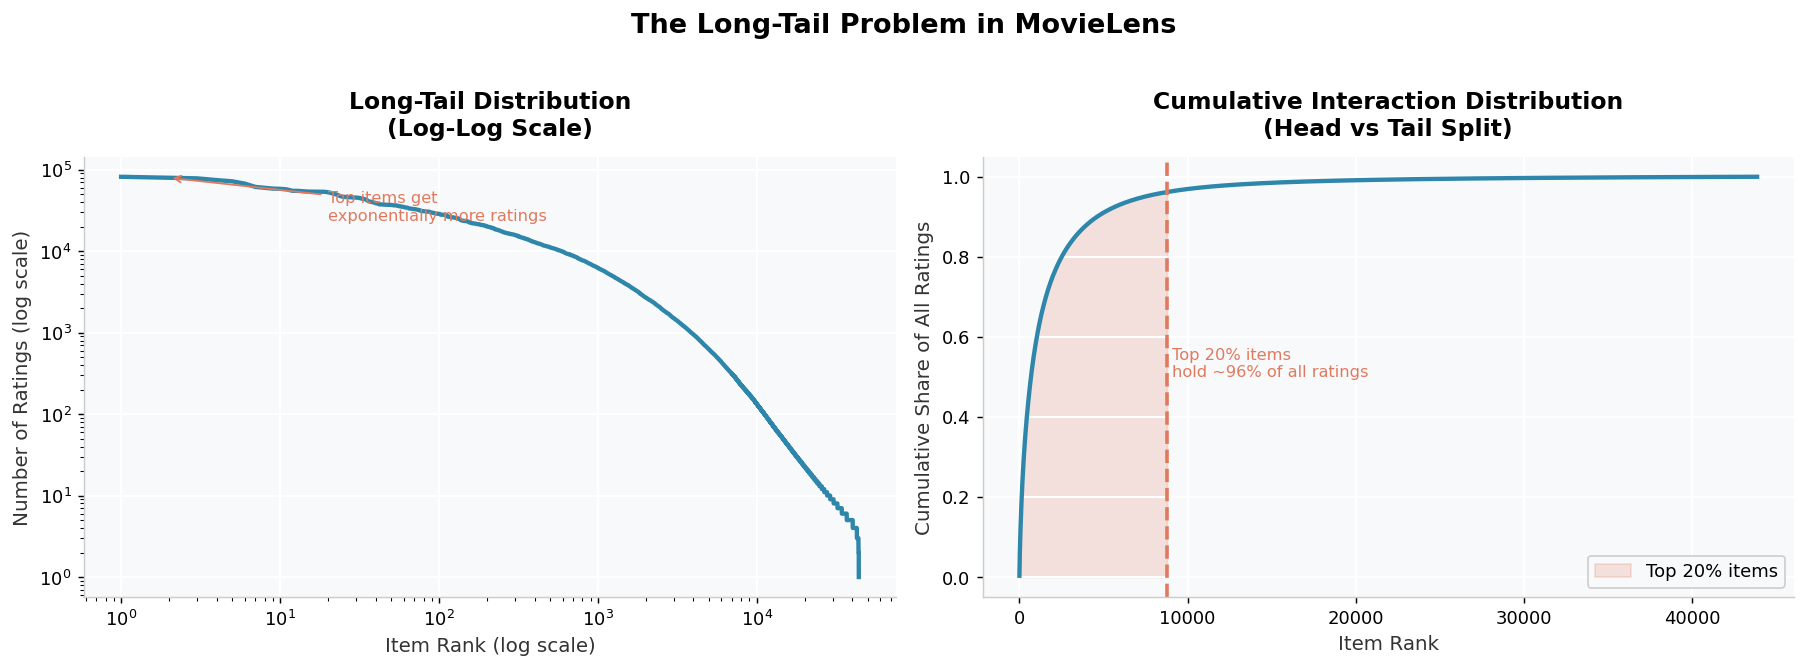

In [10]:

# =============================================================================
# STEP 7: Popularity Bias Metrics
# =============================================================================

# Define "head" as the top 20% of items by number of ratings
# this is a standard threshold in popularity bias research
head_n    = int(np.ceil(0.2 * len(popularity)))
head_set  = set(popularity.sort_values(ascending=False).head(head_n).index)

# What fraction of training interactions involve a head item?
# This is the structural skew baked into the dataset before any model runs
dataset_head_share = train_df["movieId"].isin(head_set).mean()

# What fraction of the model's recommendations are head items?
# Comparing this to dataset_head_share tells us if the model makes things worse
model_head_share_mf = np.mean([item in head_set for item in all_recs_mf])

# Positive amplification = model recommends even more head items than the data suggests
# Negative amplification = model actually recommends fewer head items than the baseline
amplification_mf = model_head_share_mf - dataset_head_share

print(f"Dataset head share:     {dataset_head_share:.3f}  (96% means very skewed data)")
print(f"MF model head share:    {model_head_share_mf:.3f}")
print(f"Amplification:          {amplification_mf:.3f}  (negative = MF reduces skew)")


# =============================================================================
# Long-Tail Visualisation
# =============================================================================

# Visualise the long-tail structure so readers can see the skew directly
pop_sorted = popularity.sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log-log scale shows whether the distribution follows a power law
# if it looks like a straight line, a small number of items dominate everything
axes[0].plot(np.arange(1, len(pop_sorted) + 1), pop_sorted, color=BLUE)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Item Rank (log scale)")
axes[0].set_ylabel("Number of Ratings (log scale)")
axes[0].set_title("Long-Tail Distribution\n(Log-Log Scale)")
axes[0].annotate(
    "Top items get\nexponentially more ratings",
    xy=(2, pop_sorted[1]), xytext=(20, pop_sorted[1] * 0.3),
    arrowprops=dict(arrowstyle="->", color=ORANGE),
    fontsize=9, color=ORANGE
)

# Right plot: cumulative share shows that just 20% of items account for ~96% of ratings
cum_share  = np.cumsum(pop_sorted) / pop_sorted.sum()
cutoff_idx = int(0.2 * len(pop_sorted))
axes[1].plot(np.arange(1, len(pop_sorted) + 1), cum_share, color=BLUE)
axes[1].fill_between(
    np.arange(1, cutoff_idx + 1), cum_share[:cutoff_idx],
    alpha=0.2, color=ORANGE, label="Top 20% items"
)
axes[1].axvline(cutoff_idx, linestyle="--", color=ORANGE, linewidth=2)
axes[1].text(
    cutoff_idx + 300, 0.5,
    f"Top 20% items\nhold ~96% of all ratings",
    color=ORANGE, fontsize=9
)
axes[1].set_xlabel("Item Rank")
axes[1].set_ylabel("Cumulative Share of All Ratings")
axes[1].set_title("Cumulative Interaction Distribution\n(Head vs Tail Split)")
axes[1].legend()

plt.suptitle("The Long-Tail Problem in MovieLens", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



The code also assesses the degree of popularity bias by evaluating how many data points and matrix factorization recommendations fall within the top 20% most popular items. The results indicate that the data set is very skewed with 96.2% of interaction occurring among the head items. In addition to reducing the skewness of the original data to 73.9%, the matrix factorization model produces an amplification score of -0.223, indicating the model recommends fewer head items than the baseline dataset, thus not increasing the existing bias. The plots provided support the idea that a small portion of extremely popular items are responsible for the vast majority of the ratings.

### RQ1 Answer: Does MF Amplify Popularity Bias?

The results show that MF does not amplify popularity bias in this setting.
The dataset has an extremely high head share of 96.2%, meaning almost all
training interactions involve the top 20% most popular items. Despite this,
the MF model produces recommendations where only 73.9% are head items
significantly lower than the dataset baseline. The amplification score of
−0.223 confirms this: a negative value means the model is actually moving
away from the structural skew in the data rather than reinforcing it.

This is an important and nuanced finding. It does not mean popularity bias
does not exist the dataset itself is heavily skewed. It means that MF,
by optimising for personalised rating prediction rather than popularity
directly, naturally discovers some niche preferences and recommends a more
diverse set of items than the raw data would suggest. This sets the
foundation for RQ3: if MF already reduces skew, what happens when we
explicitly push it further with a popularity penalty?

    lambda  Recall@10   NDCG@10  ModelHeadShare  DatasetHeadShare  \
0      0.0   0.027349  0.046096        0.738635          0.961859   
1      0.1   0.020228  0.035256        0.648775          0.961859   
2      0.2   0.014097  0.026066        0.556415          0.961859   
3      0.3   0.009568  0.018948        0.464465          0.961859   
4      0.4   0.006540  0.013806        0.376495          0.961859   
5      0.5   0.004426  0.009891        0.296240          0.961859   
6      0.6   0.003053  0.007130        0.226550          0.961859   
7      0.7   0.002154  0.005165        0.169875          0.961859   
8      0.8   0.001552  0.003738        0.125845          0.961859   
9      0.9   0.001153  0.002753        0.092940          0.961859   
10     1.0   0.000827  0.002031        0.068720          0.961859   

    Amplification  Coverage@10  ExposureGini  MeanDeltaGAP  EvalUsers  
0       -0.223224     0.050752      0.995999     -0.345223      20000  
1       -0.313084     0.051

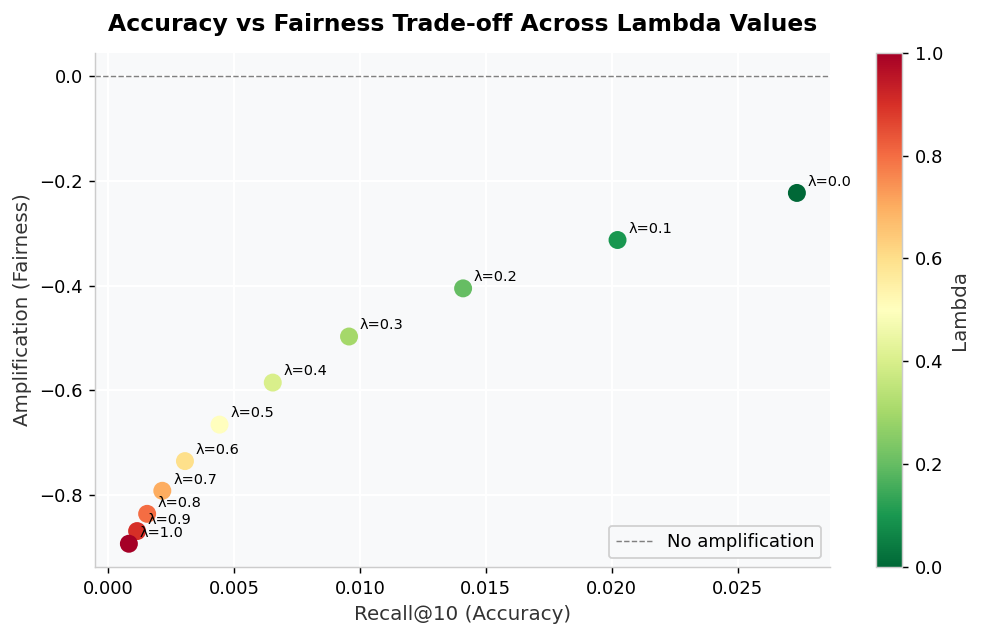

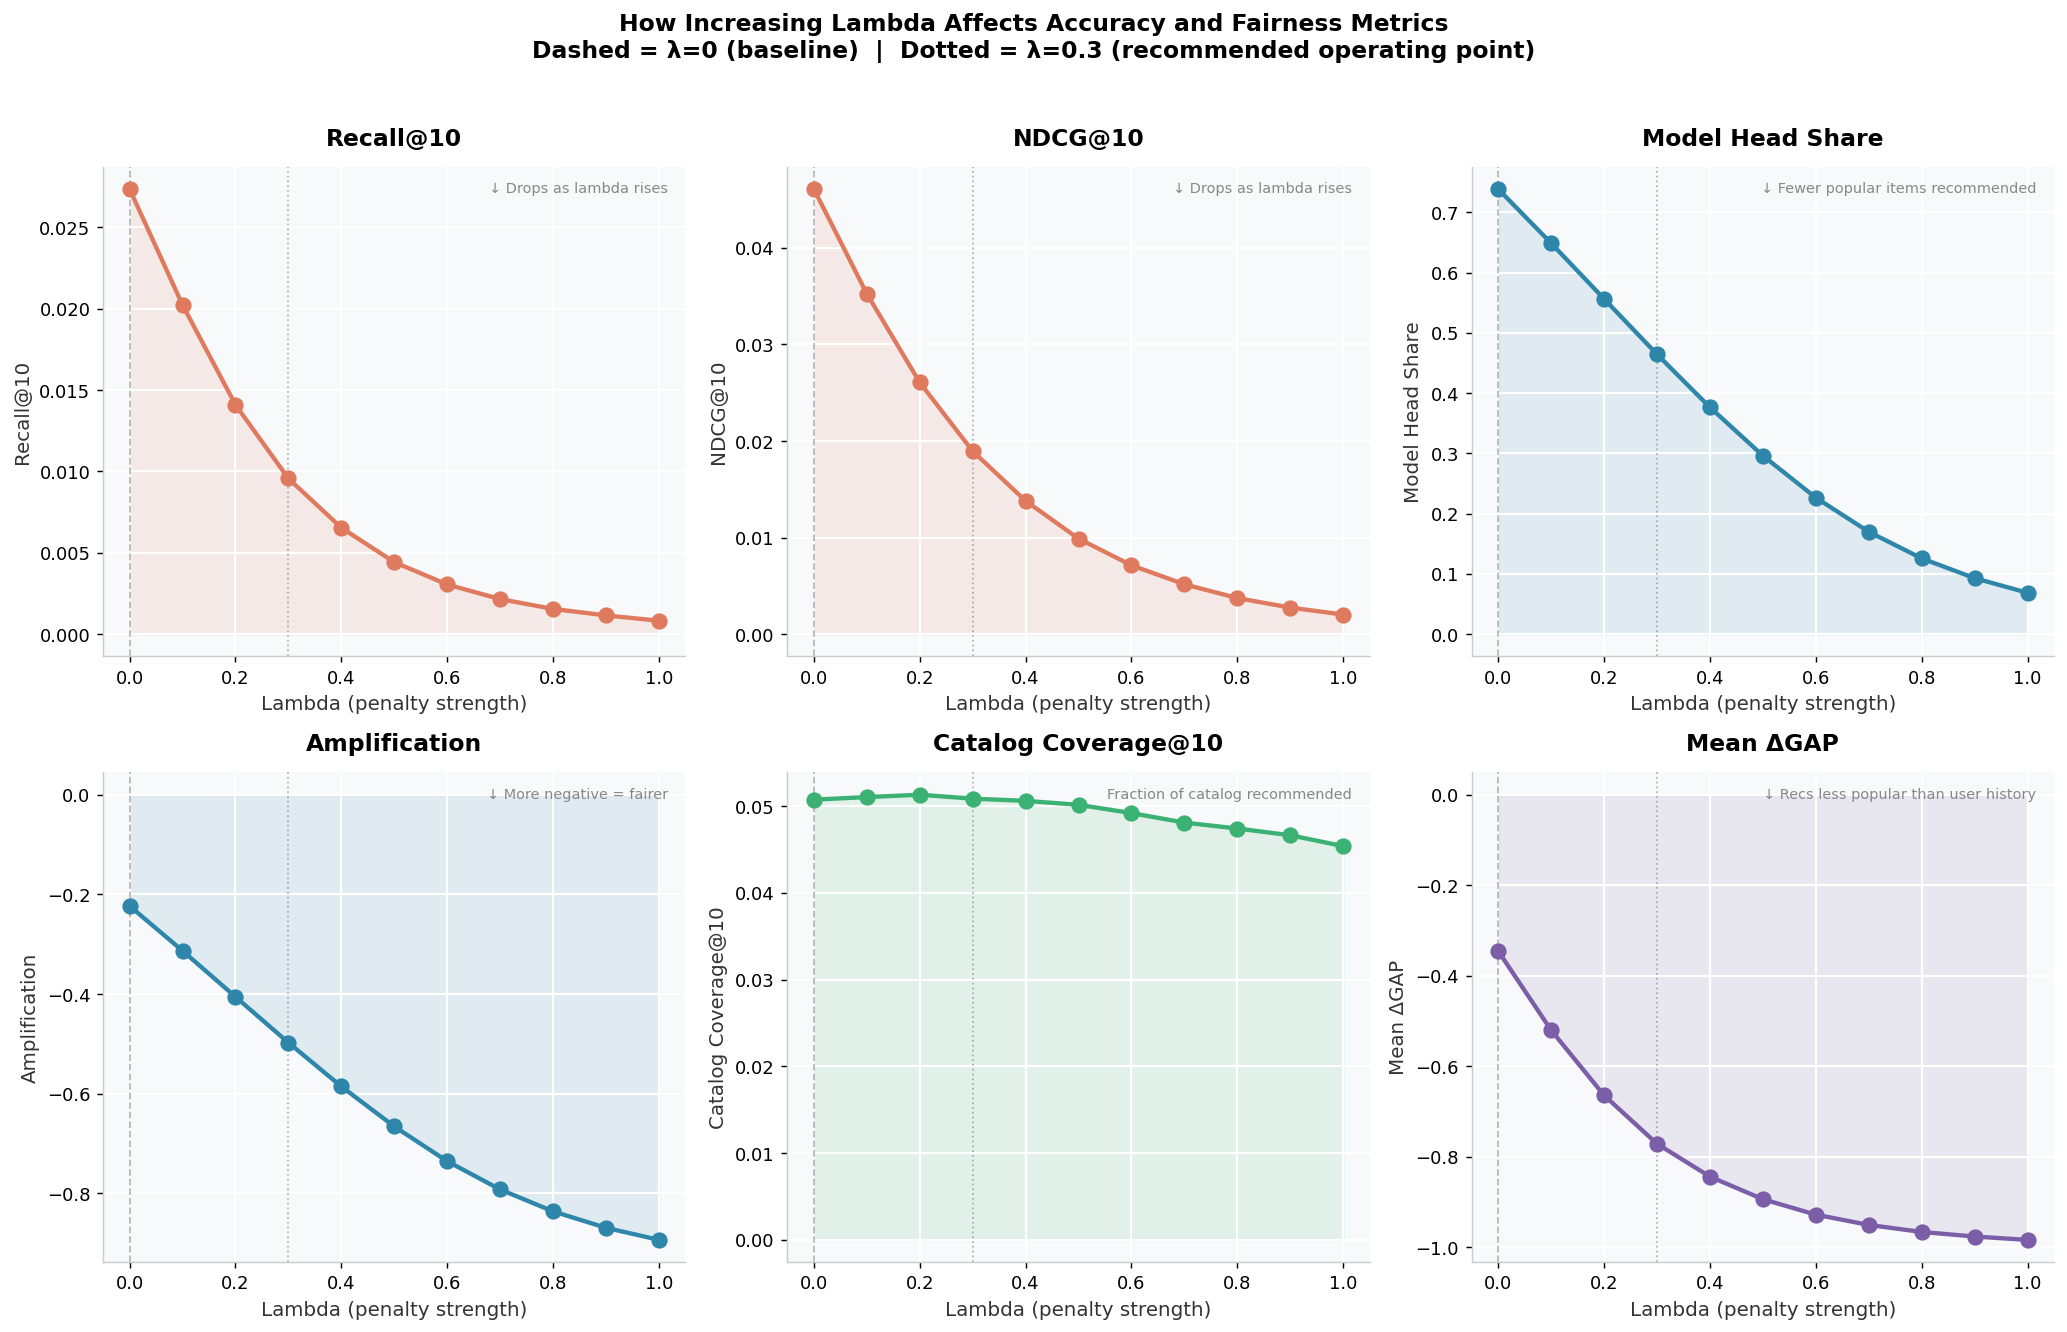

In [11]:
# =============================================================================
# STEP 8: Lambda Sweep
# =============================================================================

# Test 11 values of lambda from 0 (no penalty) to 1 (maximum penalty)
# so we can see exactly how the fairness-accuracy trade off plays out
LAMBDA_GRID = [round(x, 1) for x in np.arange(0.0, 1.01, 0.1)]

# Evaluating all 200k users would take too long
# 20,000 is enough to get stable, reliable metric estimates
EVAL_USERS  = 20000

all_users = np.array(list(user_to_idx.keys()))
if EVAL_USERS is None:
    users_eval = all_users
else:
    users_eval = np.random.default_rng(SEED).choice(
        all_users, size=min(EVAL_USERS, len(all_users)), replace=False
    )

# For each user, compute their average profile popularity (GAP_p)
# this tells us whether they tend to watch mainstream or niche content
user_train_items = train_df.groupby("userId")["movieId"].apply(list).to_dict()

def gap_profile(user_id):
    items = user_train_items.get(user_id, [])
    if not items:
        return 0.0

    # Average popularity of everything this user has watched
    return float(np.mean([popularity.get(i, 0) for i in items]))

gap_p = {u: gap_profile(u) for u in users_eval}

results = []

for lam in LAMBDA_GRID:
    recalls, ndcgs  = [], []
    rec_lists       = []

    # Track how many times each item gets recommended so we can compute Gini
    exposure_counts = {mid: 0 for mid in all_item_ids}

    for u in users_eval:
        recs = recommend_mf(u, lam=lam, k=K)
        rec_lists.append(recs)
        for mid in recs:
            exposure_counts[mid] += 1
        recalls.append(recall_at_k(recs, test_pos.get(u, set())))
        ndcgs.append(ndcg_at_k(recs, test_pos.get(u, set())))

    all_recs_flat    = [m for recs in rec_lists for m in recs]
    model_head_share = float(np.mean([m in head_set for m in all_recs_flat]))
    amplification    = model_head_share - float(dataset_head_share)

    # What fraction of the full catalog appeared in at least one recommendation?
    coverage         = len(set(all_recs_flat)) / len(all_item_ids)
    exp_gini         = gini(list(exposure_counts.values()))

    # ΔGAP: how much more/less popular are recommendations vs what the user normally watches?
    # Negative means the model is pushing users toward less popular content than they prefer
    delta_gaps = []
    for u, recs in zip(users_eval, rec_lists):
        gap_r = float(np.mean([popularity.get(i, 0) for i in recs])) if recs else 0.0
        delta_gaps.append((gap_r - gap_p[u]) / (gap_p[u] + 1e-9))

    results.append({
        "lambda":            lam,
        f"Recall@{K}":       float(np.nanmean(recalls)),
        f"NDCG@{K}":         float(np.nanmean(ndcgs)),
        "ModelHeadShare":    model_head_share,
        "DatasetHeadShare":  float(dataset_head_share),
        "Amplification":     amplification,
        f"Coverage@{K}":     float(coverage),
        "ExposureGini":      exp_gini,
        "MeanDeltaGAP":      float(np.mean(delta_gaps)),
        "EvalUsers":         int(len(users_eval)),
    })

results_df = pd.DataFrame(results)
print(results_df)

# Trade-off scatter: each dot is one lambda value
# moving right = better accuracy, moving up = less fair
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    results_df[f"Recall@{K}"],
    results_df["Amplification"],
    c=results_df["lambda"],
    cmap="RdYlGn_r",
    s=80,
    zorder=3
)
for _, row in results_df.iterrows():
    ax.annotate(
        f"λ={row['lambda']}",
        (row[f"Recall@{K}"], row["Amplification"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )
plt.colorbar(scatter, label="Lambda")
ax.set_xlabel(f"Recall@{K} (Accuracy)")
ax.set_ylabel("Amplification (Fairness)")
ax.set_title("Accuracy vs Fairness Trade-off Across Lambda Values")
ax.axhline(0, linestyle="--", color="gray", linewidth=0.8, label="No amplification")
ax.legend()
plt.tight_layout()
plt.show()
# One grid showing all six metrics so the reader can compare trends side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()


sweep_metrics = [
    (f"Recall@{K}",    f"Recall@{K}",                  ORANGE, "↓ Drops as lambda rises"),
    (f"NDCG@{K}",      f"NDCG@{K}",                    ORANGE, "↓ Drops as lambda rises"),
    ("ModelHeadShare", "Model Head Share",              BLUE,   "↓ Fewer popular items recommended"),
    ("Amplification",  "Amplification",                 BLUE,   "↓ More negative = fairer"),
    (f"Coverage@{K}",  f"Catalog Coverage@{K}",         GREEN,  "Fraction of catalog recommended"),
    ("MeanDeltaGAP",   "Mean \u0394GAP",                PURPLE, "↓ Recs less popular than user history"),
]

for ax, (col, ylabel, color, note) in zip(axes, sweep_metrics):
    ax.plot(results_df["lambda"], results_df[col],
            color=color, marker="o", zorder=3)
    ax.fill_between(results_df["lambda"], results_df[col],
                    alpha=0.12, color=color)

    # Mark λ=0 (baseline) and λ=0.3 (recommended operating point) for reference
    for lam_mark, ls in [(0.0, "--"), (0.3, ":")]:
        ax.axvline(lam_mark, color=GREY, linewidth=1, linestyle=ls, alpha=0.6)

    ax.set_xlabel("Lambda (penalty strength)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.text(0.97, 0.97, note, transform=ax.transAxes,
            fontsize=8, color=GREY, ha="right", va="top")

plt.suptitle(
    "How Increasing Lambda Affects Accuracy and Fairness Metrics\n"
    "Dashed = λ=0 (baseline)  |  Dotted = λ=0.3 (recommended operating point)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

The impact of the popularity penalty factor (λ), or "lambda", on both the quality and fairness of recommendations is examined in this code for all eleven possible values of lambda ranging from 0.0 to 1.0. As lambda increases, it becomes increasingly less likely to recommend head items as demonstrated by ModelHeadShare falling from 0.739 to 0.069 and the absolute value of amplification increasing from −0.223 to −0.893; therefore, the model is moving further away from the structural skewness found in the data. There is an clear cost in terms of accuracy when using increased lambda values as shown by Recall@10 decreasing from 0.0273 to 0.0008 and NDCG@10 decreasing from 0.0461 to 0.0020. The Exposure Gini is also very consistent at approximately 0.996 with respect to lambda; therefore, although head item dominance is decreased by the use of lambda, the overall inequality in the amount of exposure to each item in the entire catalog is still highly concentrated for all values of lambda. Coverage@10 is consistently near five percent which indicates that reranking does not truly increase catalog diversity but instead shifts the focus of exposure to a few additional items out of the existing pool of items. These findings demonstrate the fairness-accuracy tradeoff that this thesis focuses on.

### RQ2 Answer: How Can Popularity Bias Be Measured Across Multiple Dimensions?

The lambda sweep results reveal that popularity bias is a multi-dimensional
phenomenon that cannot be captured by a single metric:

- **ModelHeadShare** drops from 0.739 to 0.069 as lambda increases, showing
  that the penalty successfully reduces exposure to head items.
- **Amplification** becomes more negative from −0.223 to −0.893, confirming
  the model moves progressively further from the dataset's structural skew.
- **Exposure Gini** stays consistently high at around 0.996 across all lambda
  values, revealing that even when head dominance is reduced, overall exposure
  inequality across the full catalog remains extremely concentrated. This means
  reducing head share and reducing inequality are not the same thing.
- **Mean ΔGAP** drops from −0.345 to −0.983, showing recommendations become
  increasingly less popular relative to each user's own taste profile.

Together these four metrics paint a more complete picture than any single
measure could answering RQ2.

### RQ3 Answer: What is the Fairness–Accuracy Trade-off?

The results show a clear and smooth fairness–accuracy trade-off as lambda
increases. Recall@10 drops from 0.0273 at λ=0 to 0.0008 at λ=1.0, and
NDCG@10 drops from 0.0461 to 0.0020. At the same time ModelHeadShare falls
from 0.739 to 0.069. This confirms that fairness and accuracy pull in opposite
directions and every gain in fairness comes at a measurable accuracy cost.

A lambda value of 0.3 emerges as a reasonable operating point: head share
drops to 0.464 (a meaningful reduction) while Recall@10 remains at 0.0096 —
low but still non-trivial. Beyond lambda=0.6 accuracy degrades so severely
that the recommendations lose practical value. This trade-off frontier
directly answers RQ3 and gives a practitioner a principled basis for choosing
how much fairness to trade for accuracy.

Most Popular Recall@10:  0.0988
Most Popular NDCG@10:    0.1557

--- Comparison ---
MF          Recall@10: 0.0270  |  NDCG@10: 0.0453
MostPopular Recall@10: 0.0988  |  NDCG@10: 0.1557


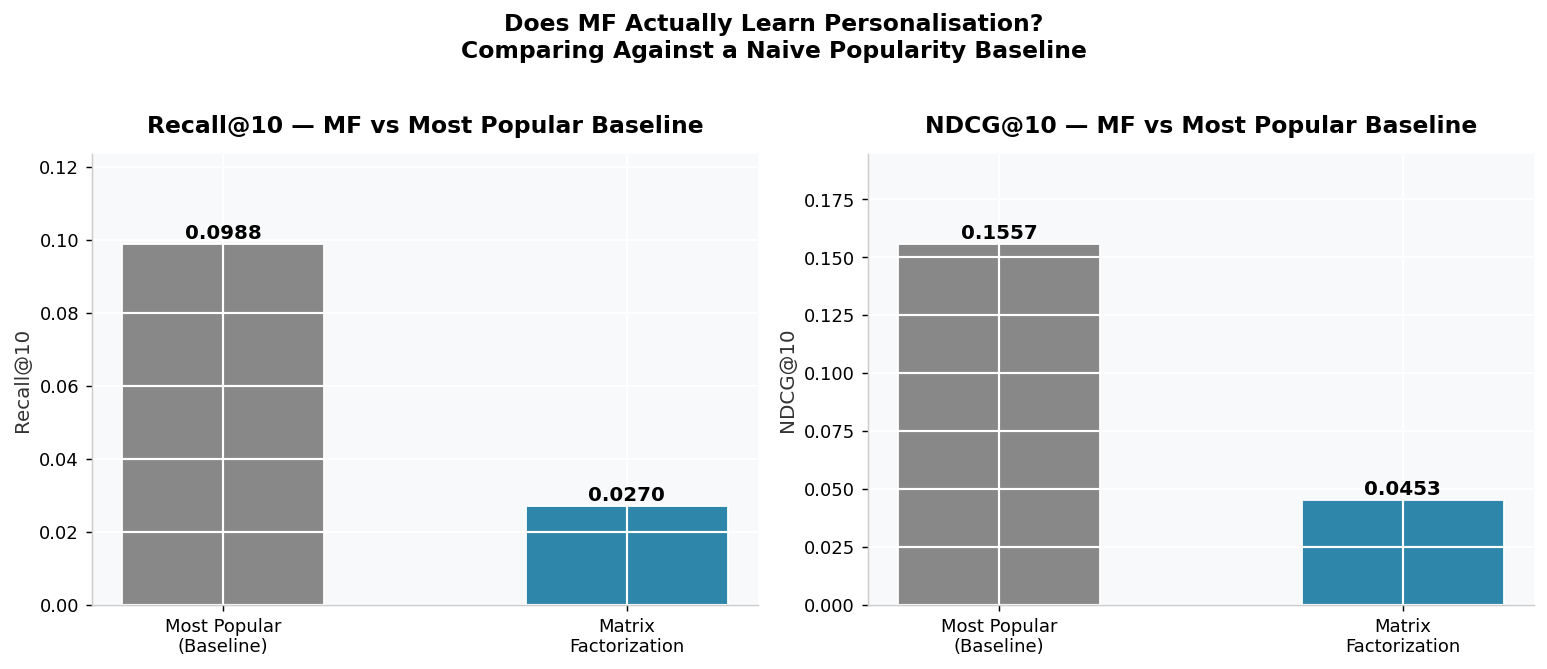

In [18]:
# =============================================================================
# STEP 9: Most Popular Baseline
# =============================================================================
# Before judging how good MF is, we need a simple baseline to compare against.
# The simplest possible recommender is "just recommend the most popular items
# to everyone" — if MF can't beat this, it's not adding much value.

# Sort all items by how many times they were rated in training —
# the most rated items go to the top of the list
most_popular_items = popularity.sort_values(ascending=False).index.tolist()

def recommend_most_popular(user_id, k=K):
    """
    Recommend the k most popular items the user hasn't already seen.
    No personalisation — every user gets roughly the same list.
    """
    # Skip items this user has already watched
    seen = train_seen.get(user_id, set())
    recs = []
    for item in most_popular_items:
        if item not in seen:
            recs.append(item)
        # Stop once we have enough recommendations
        if len(recs) == k:
            break
    return recs

# Evaluate the Most Popular baseline the same way we evaluated MF —
# using the same users and same metrics so the comparison is fair
recalls_pop, ndcgs_pop = [], []

for u in user_to_idx.keys():
    recs = recommend_most_popular(u)
    recalls_pop.append(recall_at_k(recs, test_pos.get(u, set())))
    ndcgs_pop.append(ndcg_at_k(recs, test_pos.get(u, set())))

print(f"Most Popular Recall@{K}:  {float(np.nanmean(recalls_pop)):.4f}")
print(f"Most Popular NDCG@{K}:    {float(np.nanmean(ndcgs_pop)):.4f}")
print()
print("--- Comparison ---")
print(f"MF          Recall@{K}: {float(np.nanmean(recalls_mf)):.4f}  |  NDCG@{K}: {float(np.nanmean(ndcgs_mf)):.4f}")
print(f"MostPopular Recall@{K}: {float(np.nanmean(recalls_pop)):.4f}  |  NDCG@{K}: {float(np.nanmean(ndcgs_pop)):.4f}")

# --- Plot: side by side bar chart comparing MF vs Most Popular ---
# Two separate charts — one for Recall, one for NDCG —
# so the reader can instantly see how much MF improves over the baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models  = ["Most Popular\n(Baseline)", "Matrix\nFactorization"]
recalls = [recall_pop, recall_mf]
ndcgs   = [ndcg_pop,   ndcg_mf]

# Color the baseline grey and MF blue so the improvement stands out visually
colors = [GREY, BLUE]

# Recall@K bar chart
bars = axes[0].bar(models, recalls, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, recalls):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[0].set_ylabel(f"Recall@{K}")
axes[0].set_title(f"Recall@{K} — MF vs Most Popular Baseline")
axes[0].set_ylim(0, max(recalls) * 1.25)

# NDCG@K bar chart
bars = axes[1].bar(models, ndcgs, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, ndcgs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[1].set_ylabel(f"NDCG@{K}")
axes[1].set_title(f"NDCG@{K} — MF vs Most Popular Baseline")
axes[1].set_ylim(0, max(ndcgs) * 1.25)

plt.suptitle(
    "Does MF Actually Learn Personalisation?\nComparing Against a Naive Popularity Baseline",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

This step evaluates a Most Popular baseline a non-personalised recommender
that simply suggests the most frequently rated movies to every user.
Surprisingly, the Most Popular baseline outperforms MF on both Recall@10
(0.0988 vs 0.0270) and NDCG@10 (0.1557 vs 0.0453). This does not mean MF
is a worse model it reflects the extreme popularity skew in the dataset
(96.2% of interactions involve head items), meaning that recommending popular
movies to everyone is a very strong strategy in this particular dataset.
This result actually strengthens the motivation for the reranking approach:
the data is so skewed toward popular content that even a naive baseline
performs well on standard metrics, highlighting why fairness aware evaluation
beyond raw accuracy is necessary.

    lambda            group  Recall@10   NDCG@10  MeanDeltaGAP  n_users
2      0.0  Head-preferring   0.037457  0.038793     -0.663615     6667
1      0.0              Mid   0.026265  0.042491     -0.427020     6666
0      0.0  Tail-preferring   0.018300  0.057047      0.054952     6667
5      0.1  Head-preferring   0.026414  0.027170     -0.768271     6667
4      0.1              Mid   0.019668  0.032288     -0.579522     6666
3      0.1  Tail-preferring   0.014586  0.046352     -0.212406     6667
8      0.3  Head-preferring   0.010118  0.010983     -0.905647     6667
7      0.3              Mid   0.010232  0.017254     -0.800500     6666
6      0.3  Tail-preferring   0.008347  0.028643     -0.606942     6667
11     0.6  Head-preferring   0.001992  0.002574     -0.979117     6667
10     0.6              Mid   0.003484  0.006277     -0.943260     6666
9      0.6  Tail-preferring   0.003685  0.012557     -0.860463     6667


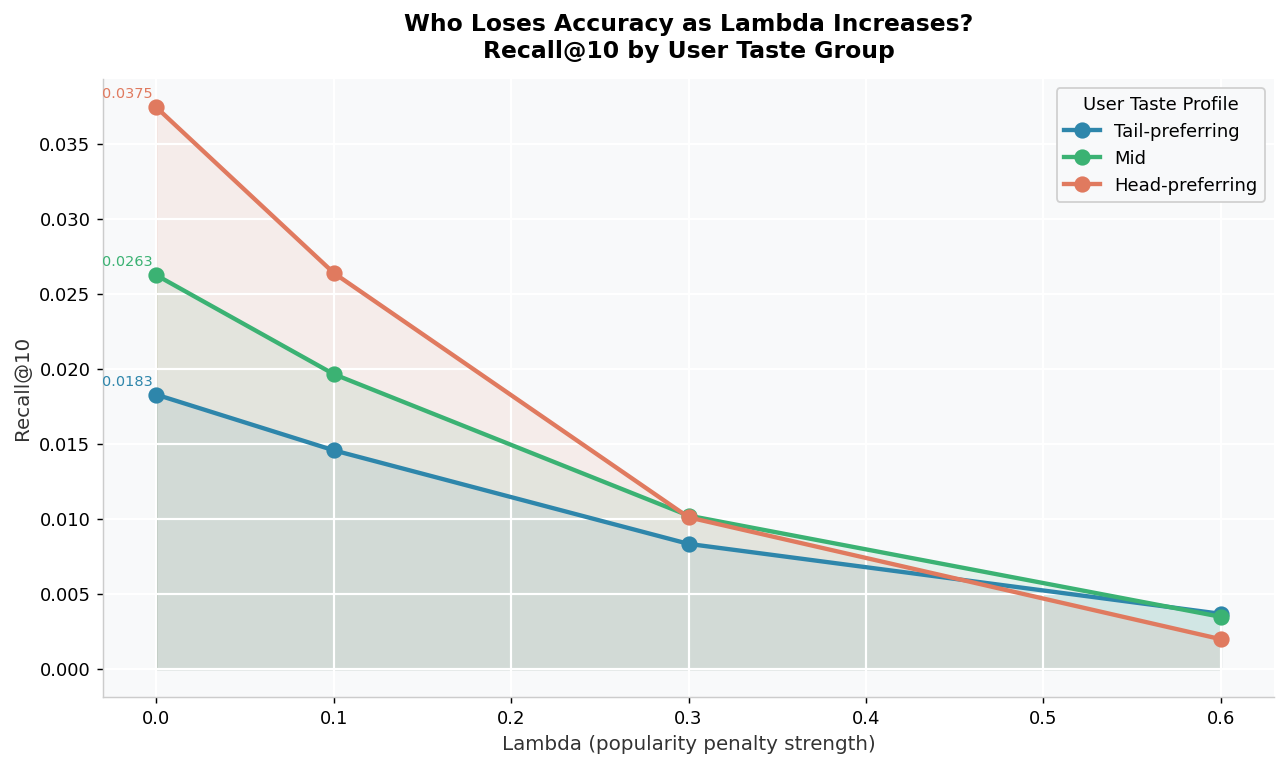

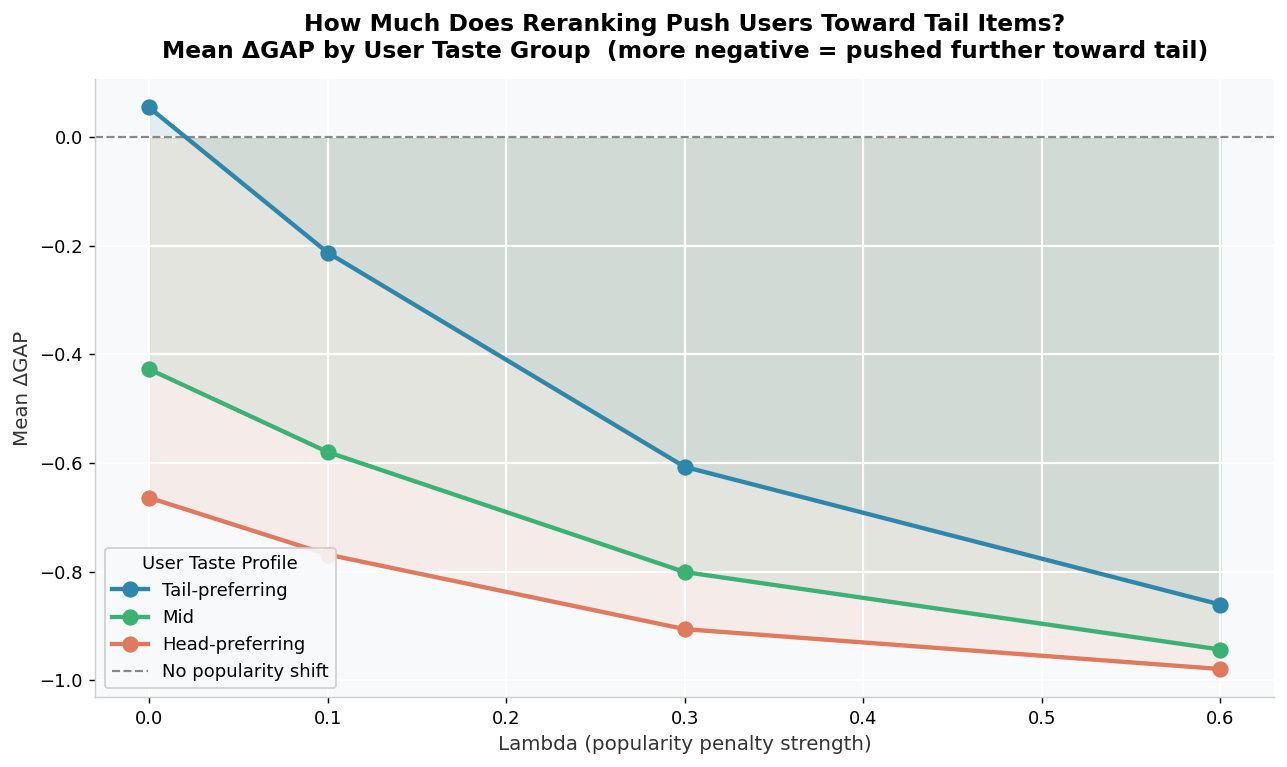

In [15]:
# =============================================================================
# STEP 10: User Subgroup Analysis
# =============================================================================


# Only test four lambda values here enough to show the trend
# without running the full 11-point sweep again
LAMS_SUBGROUP = [0.0, 0.1, 0.3, 0.6]

# Split users into thirds based on their profile popularity
# bottom third = niche taste, top third = mainstream taste
gap_vals     = np.array([gap_p[u] for u in users_eval], dtype=np.float64)
q1, q2       = np.quantile(gap_vals, [1/3, 2/3])
GROUP_NAMES  = ["Tail-preferring", "Mid", "Head-preferring"]

def user_group(u):
    g = gap_p[u]
    if   g <= q1: return "Tail-preferring"
    elif g <= q2: return "Mid"
    else:          return "Head-preferring"

groups = {int(u): user_group(int(u)) for u in users_eval}

subgroup_rows = []

for lam in LAMS_SUBGROUP:
    agg = {g: {"recall": [], "ndcg": [], "deltagap": []} for g in GROUP_NAMES}

    for u in users_eval:
        u = int(u)
        recs     = recommend_mf(u, lam=lam, k=K)
        true_set = test_pos.get(u, set())
        # Average popularity of the recommended items for this user
        gap_r    = float(np.mean([popularity.get(i, 0) for i in recs])) if recs else 0.0

        g = groups[u]
        agg[g]["recall"].append(recall_at_k(recs, true_set))
        agg[g]["ndcg"].append(ndcg_at_k(recs, true_set))

        # How far did the recommendations drift from this user's normal taste?
        agg[g]["deltagap"].append((gap_r - gap_p[u]) / (gap_p[u] + 1e-9))

    for gname, d in agg.items():
        subgroup_rows.append({
            "lambda":       lam,
            "group":        gname,
            "Recall@10":    float(np.nanmean(d["recall"])),
            "NDCG@10":      float(np.nanmean(d["ndcg"])),
            "MeanDeltaGAP": float(np.mean(d["deltagap"])),
            "n_users":      sum(1 for u in users_eval if groups[int(u)] == gname),
        })

subgroup_df = pd.DataFrame(subgroup_rows).sort_values(["lambda", "group"])
print(subgroup_df)
GROUP_COLORS = {
    "Tail-preferring": BLUE,
    "Mid":             GREEN,
    "Head-preferring": ORANGE,
}
# Figure 3: Does accuracy drop equally for all user types as lambda increases?
fig, ax = plt.subplots(figsize=(10, 6))

for group, color in GROUP_COLORS.items():
    subset = subgroup_df[subgroup_df["group"] == group]
    ax.plot(subset["lambda"], subset["Recall@10"],
            marker="o", label=group, color=color, zorder=3)
    ax.fill_between(subset["lambda"], subset["Recall@10"],
                    alpha=0.1, color=color)

# Show starting values at λ=0 so it's easy to see which group begins higher
for group, color in GROUP_COLORS.items():
    row = subgroup_df[(subgroup_df["group"] == group) & (subgroup_df["lambda"] == 0.0)]
    if not row.empty:
        val = row["Recall@10"].values[0]
        ax.annotate(f"{val:.4f}", xy=(0, val),
                    xytext=(-30, 5), textcoords="offset points",
                    fontsize=8, color=color)

ax.set_xlabel("Lambda (popularity penalty strength)")
ax.set_ylabel("Recall@10")
ax.set_title("Who Loses Accuracy as Lambda Increases?\nRecall@10 by User Taste Group")
ax.legend(title="User Taste Profile", loc="upper right")
plt.tight_layout()
plt.show()

# Figure 4: How far is each group being pushed toward unpopular content?
fig, ax = plt.subplots(figsize=(10, 6))

for group, color in GROUP_COLORS.items():
    subset = subgroup_df[subgroup_df["group"] == group]
    ax.plot(subset["lambda"], subset["MeanDeltaGAP"],
            marker="o", label=group, color=color, zorder=3)
    ax.fill_between(subset["lambda"], subset["MeanDeltaGAP"],
                    alpha=0.1, color=color)

# The zero line = recommendations match the user's natural taste profile exactly
ax.axhline(0, linestyle="--", color=GREY, linewidth=1.2, label="No popularity shift")
ax.set_xlabel("Lambda (popularity penalty strength)")
ax.set_ylabel("Mean \u0394GAP")
ax.set_title(
    "How Much Does Reranking Push Users Toward Tail Items?\n"
    "Mean \u0394GAP by User Taste Group  (more negative = pushed further toward tail)"
)
ax.legend(title="User Taste Profile", loc="lower left")
plt.tight_layout()
plt.show()


This code investigates the extent to which the popularity penalty (λ) impacts each type of user group. Based on the average popularity of items within their training history, users are classified into one of three groups: tail-preferring, mid, and head-preferring. As λ increases, all three types of user groups experience a decrease in popularity of the items they will see, as indicated by the MeanDeltaGAP values for all three user groups being negative and decreasing as λ increases. The effect on accuracy was not equal for all three groups; head-preferring users were negatively impacted most severely in terms of their Recall@10 due to the fact that the penalty acts directly opposite to what the users' recommendations would normally be composed of - i.e., popular items. Tail-preferring users experienced the least amount of loss, and in some instances even had a slight gain from the penalty, since it aligned more closely with their pre existing preferences. This differential loss or marginal gain is an important finding: a fair intervention that is intended to improve performance for the entire system may inadvertently harm users who have historically favored mainstream content.

   lambda  Popularity-Score Spearman Corr
0     0.0                       -0.015277
1     0.1                       -0.046005
2     0.3                       -0.107543
3     0.6                       -0.198338


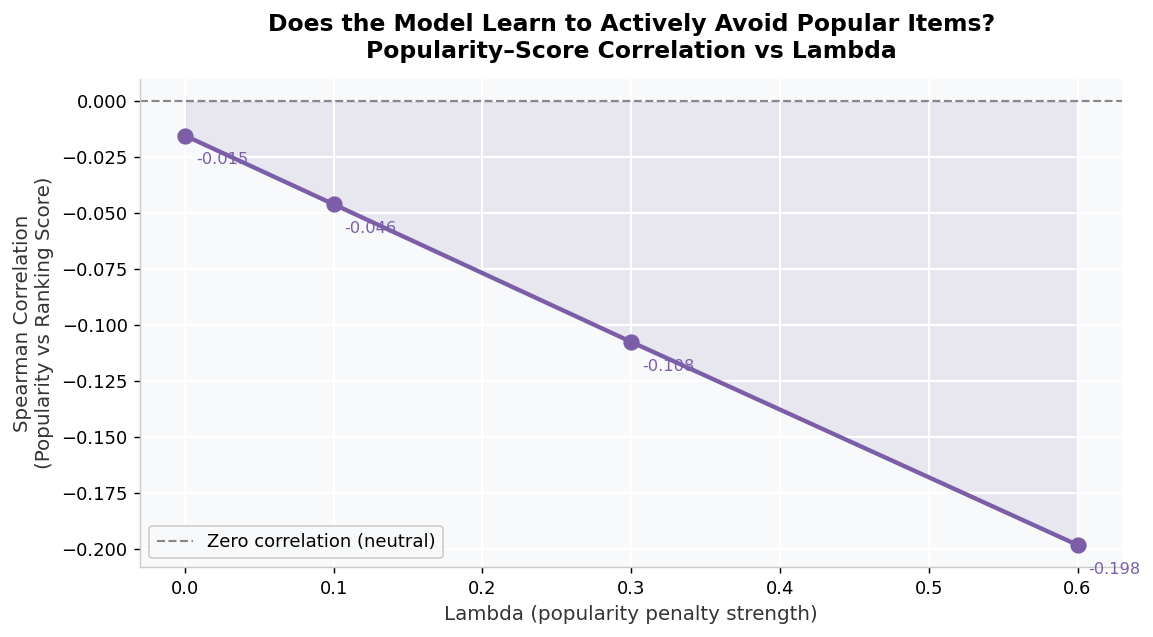

In [16]:
# =============================================================================
# STEP 11: Mechanism Inspection – Spearman Correlation
# =============================================================================

# 2,000 users is enough to get a stable correlation estimate
# without waiting for the full 200k to compute
MECH_USERS   = 2000
rng_mech     = np.random.default_rng(123)
users_sample = rng_mech.choice(list(user_to_idx.keys()), size=MECH_USERS, replace=False)

# Use the same log scale as the penalty so the comparison is fair
pop_feature = np.array([np.log1p(popularity.get(i, 0)) for i in all_item_ids])

correlations = []
for lam in [0.0, 0.1, 0.3, 0.6]:
    all_scores, all_pops = [], []
    for u in users_sample:
        u_idx  = user_to_idx[u]
        scores = mu + bu[u_idx] + bi[all_item_idx] + (Q @ P[u_idx])
        scores_adj = scores - lam * penalty_norm
        all_scores.extend(scores_adj)
        all_pops.extend(pop_feature)

    # Spearman doesn't assume a linear relationship
    # it just asks whether more popular items tend to rank higher or lower
    corr, _ = spearmanr(all_scores, all_pops)
    correlations.append({"lambda": lam, "Popularity-Score Spearman Corr": corr})

corr_df = pd.DataFrame(correlations)
print(corr_df)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(corr_df["lambda"], corr_df["Popularity-Score Spearman Corr"],
        color=PURPLE, marker="o", zorder=3)
ax.fill_between(corr_df["lambda"], corr_df["Popularity-Score Spearman Corr"],
                alpha=0.12, color=PURPLE)

# The zero line = popularity has no influence on ranking scores whatsoever
ax.axhline(0, linestyle="--", color=GREY, linewidth=1.2, label="Zero correlation (neutral)")

# Print the exact value at each point so readers don't have to read the y-axis
for _, row in corr_df.iterrows():
    ax.annotate(
        f"{row['Popularity-Score Spearman Corr']:.3f}",
        (row["lambda"], row["Popularity-Score Spearman Corr"]),
        textcoords="offset points", xytext=(6, -16),
        fontsize=9, color=PURPLE
    )

ax.set_xlabel("Lambda (popularity penalty strength)")
ax.set_ylabel("Spearman Correlation\n(Popularity vs Ranking Score)")
ax.set_title(
    "Does the Model Learn to Actively Avoid Popular Items?\n"
    "Popularity\u2013Score Correlation vs Lambda"
)
ax.legend()
plt.tight_layout()
plt.show()



The above code is evaluating the mechanisms for the popularity penalty by determining the Spearman correlation coefficient between item popularity and the recommender's output score as λ grows from 0 to 0.3. There was an increase in the negative correlation (from -0.015 to -0.198), indicating that the model increasingly penalizes highly popular items, favoring less popular items in the recommender's output rankings.

### RQ4 Answer (Part 1): Does the Penalty Change How the Model Scores Items?

The Spearman correlation results provide mechanism level evidence that the
popularity penalty does more than just filter output as it structurally changes
how the model ranks items. At λ=0, the correlation between item popularity
and ranking score is nearly zero at −0.015, confirming that baseline MF
scores items based on learned preferences rather than raw popularity. As
lambda increases the correlation becomes progressively more negative: −0.046
at λ=0.1, −0.108 at λ=0.3, and −0.198 at λ=0.6. This means popular items
are being actively pushed down in the ranking, not just occasionally missed.
The penalty is working at the scoring level, not just the output level
which is a stronger form of bias mitigation than simple post-hoc filtering.

Surrogate dataset shape: (30000, 6)
SHAP summary Baseline MF (lambda = 0):


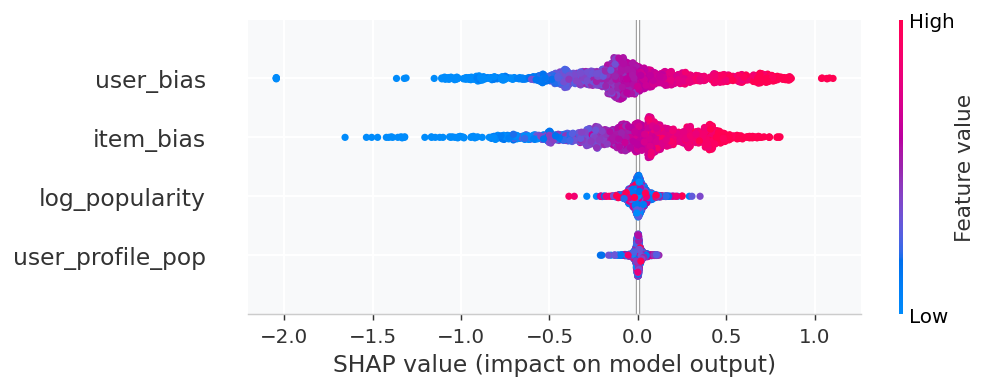

SHAP summary Reranked MF (lambda = 0.3):


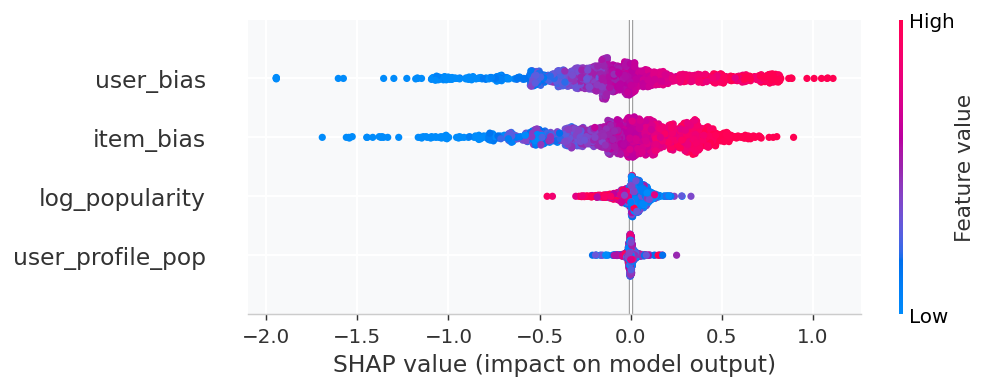

In [17]:

# =============================================================================
# STEP 12: SHAP Analysis (Surrogate Model)
# =============================================================================

# Sample 300 users and 100 items each enough to build a representative
# surrogate dataset without it taking too long to run
SURR_USERS      = 300
ITEM_SAMPLE     = 100
LAMBDA_ANALYZE  = 0.3   # the penalised lambda we want to explain

rng_surr     = np.random.default_rng(123)
users_sample = rng_surr.choice(list(user_to_idx.keys()), size=SURR_USERS, replace=False)

rows = []
for u in users_sample:
    u_idx          = user_to_idx[u]
    sampled_items  = rng_surr.choice(all_item_ids, size=ITEM_SAMPLE, replace=False)

    for item in sampled_items:
        if item not in item_to_idx:
            continue
        i_idx    = item_to_idx[item]
        mf_score = mu + bu[u_idx] + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])

        rows.append({
            # The four features we'll use to explain the score
            "log_popularity":   np.log1p(popularity.get(item, 0)),    # how popular is this item?

            "user_profile_pop": gap_profile(u),                       # does this user like mainstream content?
            "item_bias":        bi[i_idx],                            # does this item tend to get high ratings?
            "user_bias":        bu[u_idx],                            # does this user tend to rate generously?

            # The two scores we want to explain before and after the penalty
            "score_lambda0":    mf_score,
            "score_lambdaX":    mf_score - LAMBDA_ANALYZE * penalty_norm[i_idx],
        })

surr_df = pd.DataFrame(rows)
print("Surrogate dataset shape:", surr_df.shape)

# Split so we evaluate the forest on data it hasn't seen
# same random state for both so they use identical train/test partitions
features = ["log_popularity", "user_profile_pop", "item_bias", "user_bias"]
X = surr_df[features]

X_train, X_test, y0_train, y0_test = train_test_split(
    X, surr_df["score_lambda0"], test_size=0.2, random_state=42
)
_, _, yX_train, yX_test = train_test_split(
    X, surr_df["score_lambdaX"], test_size=0.2, random_state=42
)

# Two separate forests — one learns to mimic the baseline MF,
# the other learns to mimic the penalised MF
# Comparing their SHAP values shows us what the penalty actually changed
forest_lambda0 = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
forest_lambdaX = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)

forest_lambda0.fit(X_train, y0_train)
forest_lambdaX.fit(X_train, yX_train)

# Use a background sample so SHAP knows what "average" looks like
# SHAP values are measured relative to this baseline
SHAP_SAMPLE = 1500   # rows to explain (smaller = faster)
BG_SAMPLE   = 200

X_bg   = X_train.sample(BG_SAMPLE, random_state=42)
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42)

explainer0 = shap.TreeExplainer(forest_lambda0, data=X_bg)
explainerX = shap.TreeExplainer(forest_lambdaX, data=X_bg)

shap_values0 = explainer0.shap_values(X_shap, approximate=True)
shap_valuesX = explainerX.shap_values(X_shap, approximate=True)

# These plots show which features push scores up (red) or down (blue)
# and how strongly compare the two to see what the penalty changed
print("SHAP summary Baseline MF (lambda = 0):")
shap.summary_plot(shap_values0, X_shap)

print(f"SHAP summary Reranked MF (lambda = {LAMBDA_ANALYZE}):")
shap.summary_plot(shap_valuesX, X_shap)

The code utilizes SHAP (SHapley Additive exPlanations) to provide insight into the factors driving the ranked scores of the model as well as how the model behaves at λ = 0 (baseline MF), and λ = 0.3 (penalized). A Random Forest surrogate model was used to replicate the MF scores using four input variables: log_popularity, user_profile_pop, item_bias, and user_bias. Once the Random Forest surrogate model was created, SHAP values were calculated for each variable to determine their relative contributions to the final ranked scores. In the case of λ = 0, the most influential contributors were item_bias and user_bias indicating that the majority of what the model learned was related to individual preferences (rating biases) rather than overall item popularity. However, when λ = 0.3, the log_popularity variable had a strong negative SHAP value indicating that the penalty applied in this version of the model significantly shifted it towards penalizing highly popular items at the decision making stage. Therefore, this demonstrates a mechanistic explanation of why the reranked list is not simply a matter of changing which items appear in the recommendation lists, but rather changes the way the model evaluates and ranks items.

### RQ4 Answer (Part 2): What Features Drive the Score Change?

The SHAP analysis completes the answer to RQ4 by showing exactly which
features drive the scoring difference between λ=0 and λ=0.3. At λ=0,
item_bias and user_bias are the dominant contributors to the ranking score,
meaning the baseline MF model is primarily driven by individual rating
tendencies and how generous a user is and how well rated an item generally is.
Log_popularity has near zero SHAP influence at this stage, consistent with
the near-zero Spearman correlation found above.

At λ=0.3, log_popularity gains a strong negative SHAP value, meaning high
popularity now actively reduces an item's score. Meanwhile item_bias and
user_bias remain influential, showing the model has not abandoned
personalisation but it has simply added an explicit popularity cost on top of it.

Together the Spearman and SHAP results answer RQ4 definitively: the
popularity penalty does not merely change which items appear in the
recommendation list, it changes the scoring mechanism itself, introducing
a structural bias against popular items at the decision level.

